In [1]:
import os 
import torch 
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import random
import sys
import os

In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))

In [3]:
from src.utils import set_seed

set_seed(32434)

In [4]:
clases_indice = {'Windshield Fluid': 0, 'Engine': 1, 'Battery': 2, 'Engine Cover': 3, 'Air Filter': 4, 'Reservoir Cap': 5, 'Coolant Reservoir': 6}
indice_clases = {0:'Windshield Fluid', 1:'Engine', 2:'Battery', 3:'Engine Cover', 4:'Air Filter', 5:'Reservoir Cap', 6:'Coolant Reservoir',}

He estado pensando en la opción de preprocesar todo el conjunto de imágenes primero o procesar a demanda. He decidido la primera opción porque el conjunto de imágenes no es muy grande y hacer que el getitem abriese las imágenes cuando las necesitase aumentaba mucho el tiempo de entrenamiento. Actualmente estoy buscado soluciones para esto.

In [5]:
from src.utils import preprocesado_imagen

directorio = "../data/Toyota Corolla Dataset"
X = []
y = []
for carpeta in os.listdir(directorio):
    if carpeta != 'Dataset sample.png':
        ruta_carpeta = os.path.join(directorio, carpeta)
        for imagen in os.listdir(os.path.join(ruta_carpeta)):
            if not imagen.endswith(".Identifier"):
                ruta_completa = os.path.join(ruta_carpeta, imagen)
                image = preprocesado_imagen(ruta_completa)
                X.append(image)
                y.append(clases_indice[carpeta])

In [6]:
from src.dataset import ImagenDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import collections

conteo = collections.Counter(y)
print("Distribución de clases:", dict(sorted(conteo.items())))

Distribución de clases: {0: 171, 1: 212, 2: 269, 3: 187, 4: 206, 5: 11, 6: 296}


La clase 5 reservoir cap solo tiene 11 imágenes por lo que está muy desbalanceada.

In [7]:
dataset_imagenes = ImagenDataset(X, y)

In [8]:
torch.save(dataset_imagenes, "../data/dataset_preprocesado.pt")

In [9]:
dataset_imagenes = torch.load("../data/dataset_preprocesado.pt", weights_only=False)

In [10]:
len_train = int(len(dataset_imagenes) * 0.8)
len_val = int(len(dataset_imagenes) * 0.1)
len_test = len(dataset_imagenes) - len_train - len_val

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset_imagenes,(len_train, len_val, len_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)

In [11]:
from models.modelo import Modelo

modelo = Modelo().to(device)
lossfn = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.0005)
num_epochs = 100
patience = 7

/home/mateo/miniconda3/envs/Proenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mateo/miniconda3/envs/Proenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


El Modelo se trata de una ResNet18 por tranferlearning. He probado varias opciones como hacer un red convoluciocional propia o un transformer, pero ResNet18 tiene mejores resultados en test.

In [12]:
import time

def calculate_accuracy(model, data_, K=1):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in data_:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            topk = outputs.topk(K, dim=1)[1]
            correct_mask = topk.eq(targets.view(-1, 1).expand_as(topk))
            correct += correct_mask.sum().item()
            total += targets.size(0)

    accuracy = correct / total
    return accuracy

def train_model(model, optimizer, lossfn, train_loader, val_loader, patience, num_epochs):
    no_improvement = 0
    min_loss = float('inf')
    for epoch in range(num_epochs):
        start_time = time.time()

        total_train_loss = 0
        total_val_loss = 0

        model.train()
        for inputs, targets in train_loader: 
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = lossfn(outputs, targets)
            loss.backward()  
            optimizer.step()
            total_train_loss += loss.item()

        train_accuracy = calculate_accuracy(model, train_loader)

        model.eval()
        with torch.no_grad():
            for inputs, targets in val_loader:
                targets = torch.tensor(targets, dtype=torch.long)
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = lossfn(outputs, targets)
                total_val_loss += loss.item()

        val_accuracy = calculate_accuracy(model, val_loader)
        val_accuracy_3 = calculate_accuracy(model, val_loader, K=3)

        epoch_time = time.time() - start_time

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {total_train_loss/len(train_loader):.4f}, '
              f'Val Loss: {total_val_loss/len(val_loader):.4f}, '
              f'Train T1 Accuracy: {train_accuracy:.4f}, '
              f'Val T1 Accuracy: {val_accuracy:.4f}, '
              f'Val T3 Accuracy: {val_accuracy_3:.4f}, '
              f'Time: {epoch_time:.2f} sec')
        
        if total_val_loss < min_loss:
            min_loss = total_val_loss
            no_improvement = 0
        else:
            no_improvement += 1
        
        if no_improvement >= patience:
            print(f"No hay mejora por {patience} épocas. Parada Temprana!!")
            break

print(f"Entrenando CNN en {device}...")
train_model(modelo, optimizer, lossfn, train_loader, val_loader, patience, num_epochs)

Entrenando CNN en cuda...


/tmp/ipykernel_12824/2106564487.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(targets, dtype=torch.long)


Epoch [1/100], Train Loss: 1.8186, Val Loss: 1.6842, Train T1 Accuracy: 0.4440, Val T1 Accuracy: 0.4296, Val T3 Accuracy: 0.8889, Time: 3.65 sec
Epoch [2/100], Train Loss: 1.4900, Val Loss: 1.3384, Train T1 Accuracy: 0.6494, Val T1 Accuracy: 0.6222, Val T3 Accuracy: 0.8593, Time: 1.88 sec
Epoch [3/100], Train Loss: 1.0468, Val Loss: 0.8563, Train T1 Accuracy: 0.8622, Val T1 Accuracy: 0.8370, Val T3 Accuracy: 0.9704, Time: 1.92 sec
Epoch [4/100], Train Loss: 0.6747, Val Loss: 0.6489, Train T1 Accuracy: 0.8760, Val T1 Accuracy: 0.8148, Val T3 Accuracy: 0.9778, Time: 1.87 sec
Epoch [5/100], Train Loss: 0.4593, Val Loss: 0.5239, Train T1 Accuracy: 0.9214, Val T1 Accuracy: 0.8519, Val T3 Accuracy: 0.9704, Time: 1.93 sec
Epoch [6/100], Train Loss: 0.3476, Val Loss: 0.5172, Train T1 Accuracy: 0.9251, Val T1 Accuracy: 0.8593, Val T3 Accuracy: 0.9556, Time: 1.95 sec
Epoch [7/100], Train Loss: 0.3158, Val Loss: 0.5383, Train T1 Accuracy: 0.9288, Val T1 Accuracy: 0.8667, Val T3 Accuracy: 0.9704, 

In [13]:
test_accuracy = calculate_accuracy(modelo, test_loader)
print(f"Accuracy en cojunto de test {test_accuracy:.4f}")

Accuracy en cojunto de test 0.9338


In [14]:
ruta_modelo = "../models/modelo_corolla.pth"
torch.save(modelo.state_dict(), ruta_modelo)
print(f"Modelo guardado en {ruta_modelo}")

Modelo guardado en ../models/modelo_corolla.pth


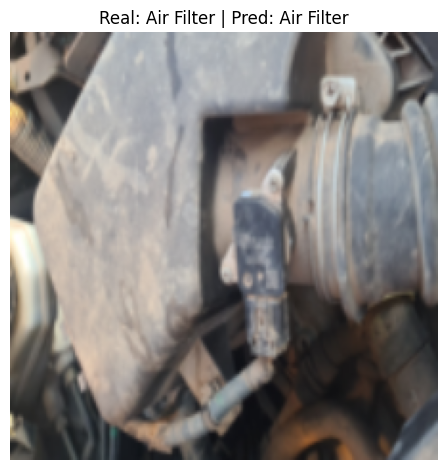

In [15]:
import matplotlib.pyplot as plt

indx = random.randint(0, len(test_dataset)-1)
imagen, etiqueta = test_dataset[indx]
imagen = imagen.to(device)
modelo.eval()
with torch.no_grad():
    output = modelo(imagen.unsqueeze(0))
imagen = imagen.to('cpu')
pred = output.argmax(1).item()
mean = torch.tensor([0.485, 0.456, 0.406]) 
std = torch.tensor([0.229, 0.224, 0.225]) 
imagen_n = imagen * std[:, None, None] + mean[:, None, None]
imagen_n = imagen_n.permute(1, 2, 0)
plt.imshow(imagen_n.squeeze())
plt.title(f"Real: {indice_clases[etiqueta]} | Pred: {indice_clases[pred]}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
from lime import lime_image

explainer = lime_image.LimeImageExplainer()
def predict_fn(images):
    modelo.eval()
    batch = []

    for img in images:
        # img es numpy HWC en rango [0,1]
        img = torch.tensor(img).permute(2, 0, 1).float()

        # Normalizar igual que en tu dataset
        img = (img - mean[:, None, None]) / std[:, None, None]

        batch.append(img)

    batch = torch.stack(batch).to(device)

    with torch.no_grad():
        outputs = modelo(batch)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()


/home/mateo/miniconda3/envs/Proenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
imagen_n = imagen_n.cpu().numpy()
explanation = explainer.explain_instance(imagen_n, 
                                         predict_fn, 
                                         hide_color=0, 
                                         top_labels=1,
                                         num_samples=2000)

100%|██████████| 2000/2000 [00:05<00:00, 384.73it/s]


In [18]:
[indice_clases[i] for i in explanation.top_labels]

['Air Filter']

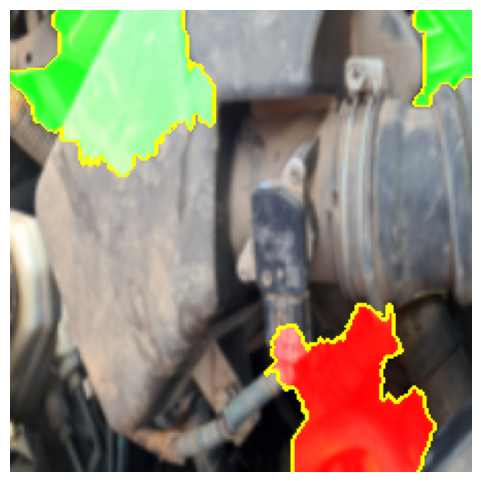

In [19]:
from skimage.segmentation import mark_boundaries

# Display the explanation using matplotlib
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], 
                                            positive_only=False, 
                                            num_features=5, 
                                            hide_rest=False)
# Asegurar rango correcto 
temp = temp.astype(float) 
temp = (temp - temp.min()) / (temp.max() - temp.min() + 1e-8) 
plt.figure(figsize=(6,6)) 
plt.imshow(mark_boundaries(temp, mask)) 
plt.axis('off') 
plt.show()

He añadido una explicación lime para doder observar que partes de la imagen son más importantes para que el modelo decida su predicción.

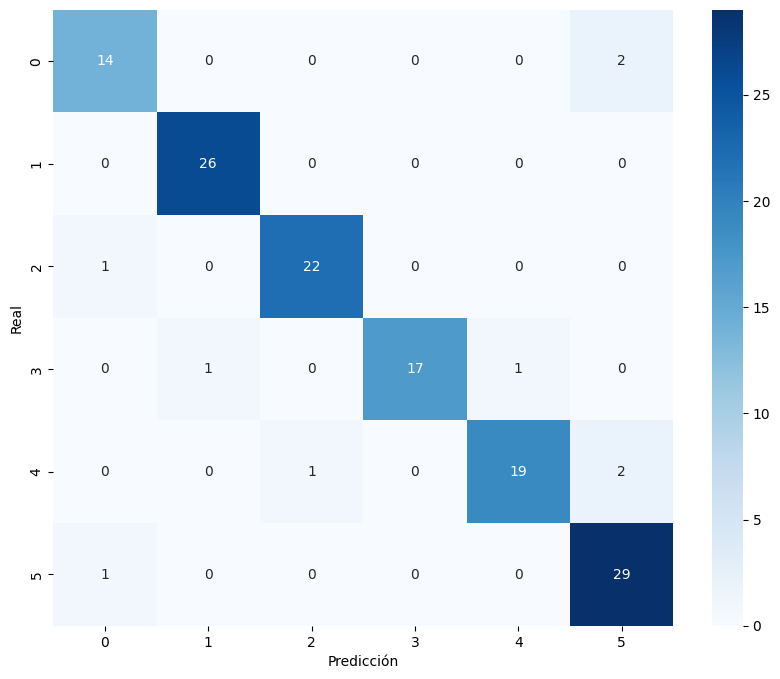

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader):
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(targets.numpy())
            y_pred.extend(preds.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

plot_confusion_matrix(modelo, test_loader)

Tambien he añadido una matriz de confusión para visualizar que clases falla. Podemos ver que aunque tengamos 7 clases, en la matriz de confusión solo aparecen 6. Esto se debe a que ninguna de las 11 imágenes de la clase 5 Reservoir Cap ha acabado en el conjunto de test. Actualmente estoy buscando soluciones para esto.

Para visualizar los datos he elegido un autoencoder variacional ya que se tratan de datos de gran dimensionalidad. Para entrenar el VAE es necesario volver a cargar y procesar las imagenes pero esta vez sin normalizar. He tenido que reescalar las imágenes a 28x28 para que mi pc pudiese entrenarlo.

In [21]:
from src.utils import preprocesado_imagenVAE

directorio = "../data/Toyota Corolla Dataset"
X = []
y = []
for carpeta in os.listdir(directorio):
    if carpeta != 'Dataset sample.png':
        ruta_carpeta = os.path.join(directorio, carpeta)
        for imagen in os.listdir(os.path.join(ruta_carpeta)):
            if not imagen.endswith(".Identifier"):
                ruta_completa = os.path.join(ruta_carpeta, imagen)
                image = preprocesado_imagenVAE(ruta_completa)
                X.append(image)
                y.append(clases_indice[carpeta])

dataset_imagenes = ImagenDataset(X, y)
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset_imagenes,(len_train, len_val, len_test))



train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
imagenes_loader = DataLoader(dataset_imagenes, batch_size=64, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)

In [22]:
from models.modelo import VAE

MSE_loss = nn.MSELoss(reduction='mean')

modelo = VAE().to(device)
optimizer = optim.Adam(modelo.parameters(), lr=0.001)
num_epochs = 500

In [ ]:
def trainVAE(modelo, optimizer, MSE_loss, train_loader, val_loader, num_epochs):

    for epoch in range(num_epochs):

        # ---------------------- ENTRENAMIENTO ----------------------
        modelo.train()
        train_loss = 0

        for img, _ in train_loader:
            img = img.to(device)

            recon, mu, logvar = modelo(img)
            kul = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / img.size(0)
            mse = MSE_loss(recon, img)
            loss = kul + mse

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---------------------- VALIDACIÓN ----------------------
        modelo.eval()
        val_loss = 0

        with torch.no_grad():
            for img, _ in val_loader:
                img = img.to(device)

                recon, mu, logvar = modelo(img)
                kul = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / img.size(0)
                mse = MSE_loss(recon, img)
                loss = kul + mse

                val_loss += loss.item()

        val_loss /= len(val_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

        # ---------------------- VISUALIZACIÓN ----------------------
        # He decidido quitar la visualización.
        """
        val_img, _ = next(iter(val_loader))
        val_img = val_img.to(device)

        with torch.no_grad():
            val_output, _, _ = modelo(val_img)
        
        
        plt.figure(figsize=(9, 3))

        # Original
        plt.subplot(1, 2, 1)
        plt.title("Imagen Original")
        plt.imshow(val_img[0].cpu().permute(1, 2, 0))
        plt.axis('off')

        # Reconstruida
        plt.subplot(1, 2, 2)
        plt.title("Reconstrucción")
        plt.imshow(val_output[0].cpu().permute(1, 2, 0))
        plt.axis('off')

        plt.show()
        """

trainVAE(modelo, optimizer, MSE_loss, train_loader, val_loader, num_epochs)

Epoch [1/500]  Train Loss: 0.0371  Val Loss: 0.0365
Epoch [2/500]  Train Loss: 0.0360  Val Loss: 0.0359
Epoch [3/500]  Train Loss: 0.0356  Val Loss: 0.0356
Epoch [4/500]  Train Loss: 0.0354  Val Loss: 0.0354
Epoch [5/500]  Train Loss: 0.0352  Val Loss: 0.0351
Epoch [6/500]  Train Loss: 0.0350  Val Loss: 0.0349
Epoch [7/500]  Train Loss: 0.0348  Val Loss: 0.0346
Epoch [8/500]  Train Loss: 0.0347  Val Loss: 0.0344
Epoch [9/500]  Train Loss: 0.0347  Val Loss: 0.0346
Epoch [10/500]  Train Loss: 0.0346  Val Loss: 0.0345
Epoch [11/500]  Train Loss: 0.0346  Val Loss: 0.0345
Epoch [12/500]  Train Loss: 0.0346  Val Loss: 0.0344
Epoch [13/500]  Train Loss: 0.0346  Val Loss: 0.0345
Epoch [14/500]  Train Loss: 0.0345  Val Loss: 0.0344
Epoch [15/500]  Train Loss: 0.0346  Val Loss: 0.0344
Epoch [16/500]  Train Loss: 0.0346  Val Loss: 0.0344
Epoch [17/500]  Train Loss: 0.0345  Val Loss: 0.0345
Epoch [18/500]  Train Loss: 0.0345  Val Loss: 0.0344
Epoch [19/500]  Train Loss: 0.0345  Val Loss: 0.0345
Ep

In [24]:
modelo.eval()

latents = []
labels = []

with torch.no_grad():
    for imgs, lbls in imagenes_loader:
        imgs = imgs.to(device)
        _, mu, _ = modelo(imgs)
        
        latents.append(mu.cpu())
        labels.append(lbls)

latents = torch.cat(latents, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()


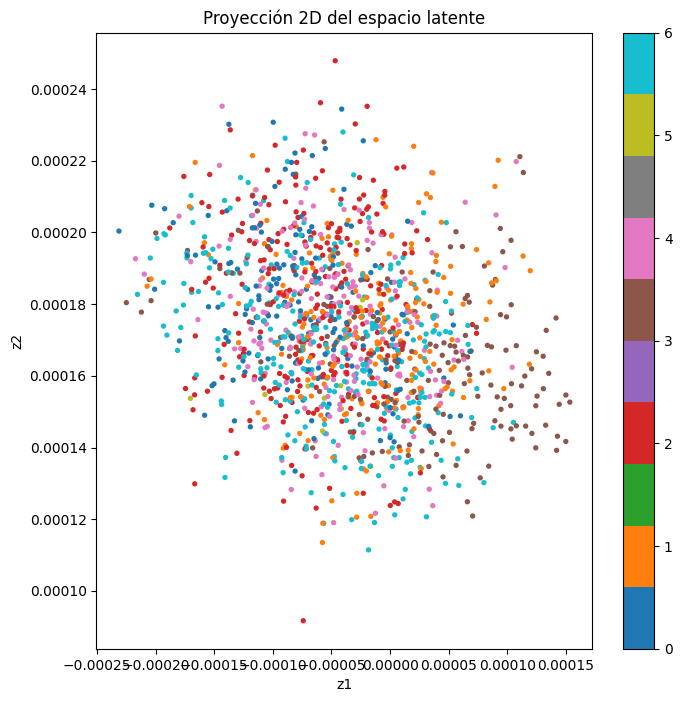

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', s=8)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Proyección 2D del espacio latente")
plt.colorbar()
plt.show()

La representación latente no es muy buena. Primero no está centrado en el (0,0); segundo el VAE no ha podido separar las clases por clusteres. Esto seguramente se deba al limitante de haber tenido que reescalar las imágenes a 28x28 ya que se pierde información. Aun asi no todo es malo, si nos fijamos muchos de los puntos tienen omo vecinos puntos de su misma clase.